# Launch data analysis

Step 1: load and clean the launch data pulled by `fetch_data.py`.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/launches.csv", parse_dates=["net"])
print(df.shape)
df.info()
df.head()

(1500, 15)
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   id             1500 non-null   str                
 1   name           1500 non-null   str                
 2   net            1500 non-null   datetime64[us, UTC]
 3   status         1500 non-null   str                
 4   fail_reason    52 non-null     str                
 5   provider       1500 non-null   str                
 6   provider_type  1500 non-null   str                
 7   rocket         1500 non-null   str                
 8   rocket_family  1319 non-null   str                
 9   mission_type   1494 non-null   str                
 10  orbit          1494 non-null   str                
 11  orbit_abbrev   1478 non-null   str                
 12  pad            1500 non-null   str                
 13  location       1500 non-null   str              

,id,name,net,status,fail_reason,provider,provider_type,rocket,rocket_family,mission_type,orbit,orbit_abbrev,pad,location,country_code
0,42370bdb-db93-4212-bda6-d91c177b2ea6,H-IIA 202 | Hope (Emirates Mars Mission),2020-07-19 21:58:14+00:00,Launch Successful,NaN,Mitsubishi Heavy Industries,Commercial,H-IIA,H-II,Planetary Science,Heliocentric N/A,Helio-N/A,Yoshinobu Launch Complex LP-1,"Tanegashima Space Center, Japan",JPN
1,7e9fd521-c3af-4c55-9873-93bfe9945749,Falcon 9 Block 5 | ANASIS-II,2020-07-20 21:30:00+00:00,Launch Successful,NaN,SpaceX,Commercial,Falcon 9,Falcon,Government/Top Secret,Geostationary Transfer Orbit,GTO,Space Launch Complex 40,"Cape Canaveral SFS, FL, USA",USA
2,485b9786-5bec-4dd4-ac82-69d1fd702047,Long March 5 | Tianwen-1 (Mars Global Remote S...,2020-07-23 04:41:15+00:00,Launch Successful,NaN,China Aerospace Science and Technology Corpora...,Government,Long March 5,Long March,Robotic Exploration,Heliocentric N/A,Helio-N/A,101,"Wenchang Space Launch Site, People's Republic ...",CHN
3,c7f03e53-e4e3-42e3-9d57-71666ad80c18,Soyuz 2.1a | Progress MS-15 (76P),2020-07-23 14:26:22+00:00,Launch Successful,NaN,Russian Federal Space Agency (ROSCOSMOS),Government,Soyuz 2.1a,Soyuz,Resupply,Low Earth Orbit,LEO,31/6,"Baikonur Cosmodrome, Republic of Kazakhstan",KAZ
4,e3832ff6-fec4-4f03-8d56-820bb318d1e9,Long March 4B | Ziyuan-3-03,2020-07-25 03:13:00+00:00,Launch Successful,NaN,China Aerospace Science and Technology Corpora...,Government,Long March 4B,Long March,Earth Science,Sun-Synchronous Orbit,SSO,Launch Complex 9,"Taiyuan Satellite Launch Center, People's Repu...",CHN


Check which status labels exist before deciding what counts as success or failure.

In [10]:
df["status"].value_counts()

status
Launch Successful               1434
Launch Failure                    60
Launch was a Partial Failure       6
Name: count, dtype: int64

## Clean

Keep only launches that have an outcome (drops scheduled or unknown ones). If the labels above differ from the map below, edit the map.

In [11]:
outcome_map = {
    "Launch Successful": "success",
    "Launch Failure": "failure",
    "Launch was a Partial Failure": "partial failure",
}

df["outcome"] = df["status"].map(outcome_map)
df = df.dropna(subset=["outcome"]).copy()
df["success"] = df["outcome"] == "success"
df["year"] = df["net"].dt.year

print(df.shape)
df["outcome"].value_counts()

(1500, 18)


outcome
success            1434
failure              60
partial failure       6
Name: count, dtype: int64

Tidy text columns and handle missing values.

In [12]:
text_cols = ["provider", "rocket", "rocket_family", "orbit", "orbit_abbrev", "country_code"]
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

df[["orbit", "orbit_abbrev"]] = df[["orbit", "orbit_abbrev"]].fillna("Unknown")

df.isna().mean().sort_values(ascending=False)

fail_reason      0.965333
rocket_family    0.120667
mission_type     0.004000
id               0.000000
name             0.000000
net              0.000000
provider         0.000000
status           0.000000
rocket           0.000000
provider_type    0.000000
orbit            0.000000
orbit_abbrev     0.000000
pad              0.000000
location         0.000000
country_code     0.000000
outcome          0.000000
success          0.000000
year             0.000000
dtype: float64

Look at the categories before grouping anything. Orbit and provider names often need merging.

In [13]:
print(df["orbit_abbrev"].value_counts().head(15))
print(df["provider"].value_counts().head(15))

orbit_abbrev
LEO           786
SSO           303
GTO           128
PO             79
Sub            77
MEO            34
Unknown        22
Direct-GEO     15
LO             14
Elliptical     14
Helio-N/A       9
GSO             5
GSTO            3
L2              3
L1-point        2
Name: count, dtype: Int64
provider
SpaceX                                                630
China Aerospace Science and Technology Corporation    329
Rocket Lab                                             83
Russian Federal Space Agency (ROSCOSMOS)               54
Russian Space Forces                                   46
Arianespace                                            42
United Launch Alliance                                 35
Blue Origin                                            29
Indian Space Research Organization                     29
ExPace                                                 25
Galactic Energy                                        25
Mitsubishi Heavy Industries                 

## First chart

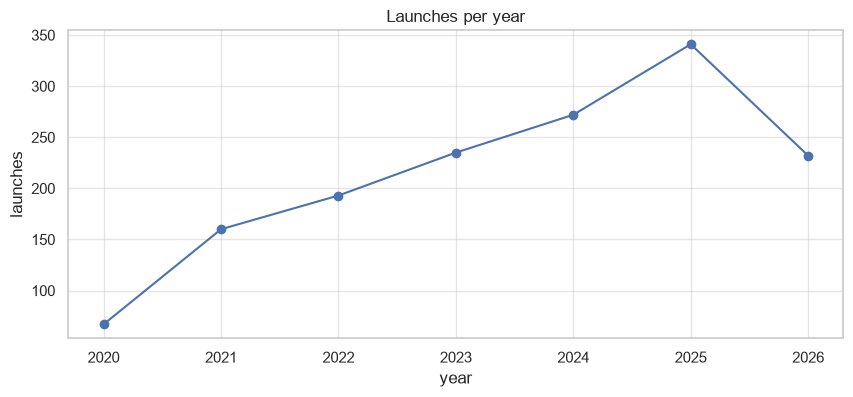

In [14]:
launches_per_year = df.groupby("year").size()
launches_per_year.plot(kind="line", marker="o", figsize=(10, 4), title="Launches per year")
plt.ylabel("launches")
plt.show()

Save the cleaned version so later notebooks can start from it.

In [15]:
df.to_csv("data/launches_clean.csv", index=False)